<a href="https://colab.research.google.com/github/brhie/Phillips-Curve-Visualization/blob/main/Phillips_Curve_by_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phillips Curve: Relationship between inflation rate and unemployment rate

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

inflation = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/US_data1.xlsx")
unemployment = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/US_data2.xlsx")
print(inflation.head())
print(unemployment.head())

   Year      Jan      Feb      Mar      Apr      May      Jun      Jul  \
0  2010  216.687  216.741  217.631  218.009  218.178  217.965  218.011   
1  2011  220.223  221.309  223.467  224.906  225.964  225.722  225.922   
2  2012  226.665  227.663  229.392  230.085  229.815  229.478  229.104   
3  2013  230.280  232.166  232.773  232.531  232.945  233.504  233.596   
4  2014  233.916  234.781  236.293  237.072  237.900  238.343  238.250   

       Aug      Sep      Oct      Nov      Dec    HALF1    HALF2  
0  218.312  218.439  218.711  218.803  219.179  217.535  218.576  
1  226.545  226.889  226.421  226.230  225.672  223.598  226.280  
2  230.379  231.407  231.317  230.221  229.601  228.850  230.338  
3  233.877  234.149  233.546  233.069  233.049  232.366  233.548  
4  237.852  238.031  237.433  236.151  234.812  236.384  237.088  
   Year  Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
0  2010  9.8  9.8  9.9  9.9  9.6  9.4  9.4  9.5  9.5  9.4  9.8  9.3
1  2011  9.1  9.0

In [ ]:
columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
inflation_df = inflation.melt(id_vars=["Year"], value_vars=columns, var_name="Month", value_name="rate")
unemployment_df = unemployment.melt(id_vars=["Year"], value_vars=columns, var_name="Month", value_name="rate")
print(inflation_df.info())
print(unemployment_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    192 non-null    int64  
 1   Month   192 non-null    object 
 2   rate    183 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    192 non-null    int64  
 1   Month   192 non-null    object 
 2   rate    183 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.6+ KB
None


In [ ]:
print(inflation_df[inflation_df['rate'].isna()])
print(unemployment_df[unemployment_df['rate'].isna()])

     Year Month  rate
63   2025   Apr   NaN
79   2025   May   NaN
95   2025   Jun   NaN
111  2025   Jul   NaN
127  2025   Aug   NaN
143  2025   Sep   NaN
159  2025   Oct   NaN
175  2025   Nov   NaN
191  2025   Dec   NaN
     Year Month  rate
63   2025   Apr   NaN
79   2025   May   NaN
95   2025   Jun   NaN
111  2025   Jul   NaN
127  2025   Aug   NaN
143  2025   Sep   NaN
159  2025   Oct   NaN
175  2025   Nov   NaN
191  2025   Dec   NaN


In [ ]:
def convert_to_date(row):
    return pd.to_datetime(f"{row['Year']}-{row['Month']}")
inflation_df['date'] = inflation_df.apply(convert_to_date, axis=1)
unemployment_df['date'] = unemployment_df.apply(convert_to_date, axis=1)
print(inflation_df.head())
print(unemployment_df.head())

   Year Month     rate       date
0  2010   Jan  216.687 2010-01-01
1  2011   Jan  220.223 2011-01-01
2  2012   Jan  226.665 2012-01-01
3  2013   Jan  230.280 2013-01-01
4  2014   Jan  233.916 2014-01-01
   Year Month  rate       date
0  2010   Jan   9.8 2010-01-01
1  2011   Jan   9.1 2011-01-01
2  2012   Jan   8.3 2012-01-01
3  2013   Jan   8.0 2013-01-01
4  2014   Jan   6.6 2014-01-01


In [ ]:
inflation_df.sort_values(by='date', inplace=True)
unemployment_df.sort_values(by='date', inplace=True)
print(inflation_df.head())
print(unemployment_df.head())

    Year Month     rate       date
0   2010   Jan  216.687 2010-01-01
16  2010   Feb  216.741 2010-02-01
32  2010   Mar  217.631 2010-03-01
48  2010   Apr  218.009 2010-04-01
64  2010   May  218.178 2010-05-01
    Year Month  rate       date
0   2010   Jan   9.8 2010-01-01
16  2010   Feb   9.8 2010-02-01
32  2010   Mar   9.9 2010-03-01
48  2010   Apr   9.9 2010-04-01
64  2010   May   9.6 2010-05-01


In [ ]:
print(inflation_df['rate'].describe(), unemployment_df['rate'].describe())

count    183.000000
mean     255.195328
std       29.405097
min      216.687000
25%      233.651500
50%      245.519000
75%      270.445500
max      319.799000
Name: rate, dtype: float64 count    183.000000
mean       5.770492
std        2.228858
min        3.400000
25%        3.900000
50%        5.000000
75%        7.500000
max       14.800000
Name: rate, dtype: float64


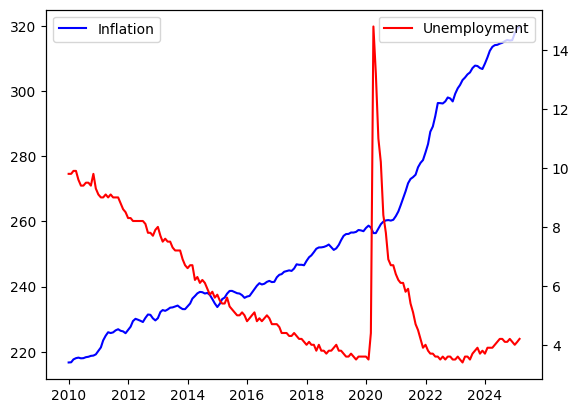

In [ ]:
fig, ax = plt.subplots()
ax.plot(inflation_df['date'], inflation_df['rate'], label='Inflation', color='blue')
ax2 = ax.twinx()
ax2.plot(unemployment_df['date'], unemployment_df['rate'], label='Unemployment', color='red')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

### What happened in 2020? Maybe because of covid, the economy has undergone a vast change.

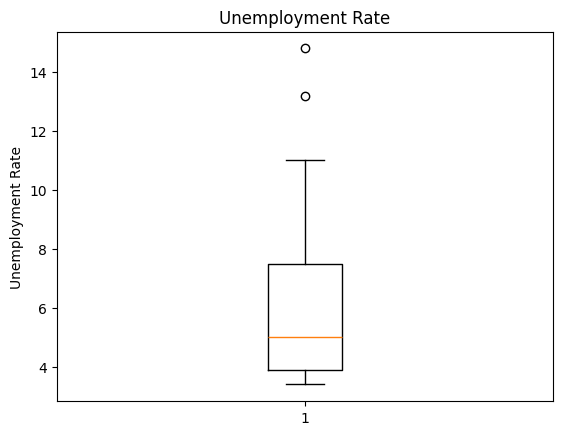

In [ ]:
unemployment_se = unemployment_df['rate'].dropna()
plt.boxplot(unemployment_se)
plt.title('Unemployment Rate')
plt.ylabel('Unemployment Rate')
plt.show()

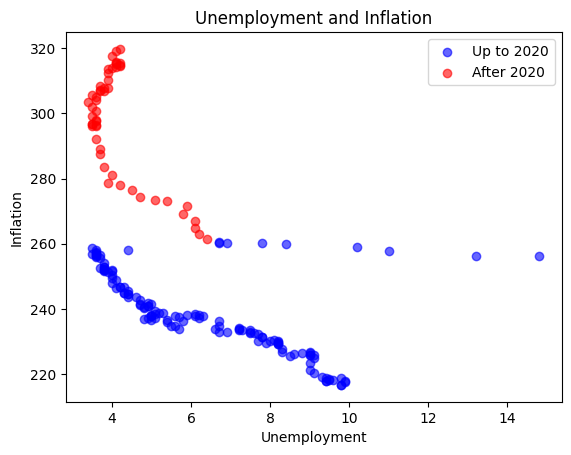

In [ ]:
unemployment_before = unemployment_df[unemployment_df['date'].dt.year <= 2020]
unemployment_after = unemployment_df[unemployment_df['date'].dt.year > 2020]
inflation_before = inflation_df[inflation_df['date'].dt.year <= 2020]
inflation_after = inflation_df[inflation_df['date'].dt.year > 2020]

plt.scatter(unemployment_before['rate'], inflation_before['rate'], color='blue', label='Up to 2020', alpha=0.6)
plt.scatter(unemployment_after['rate'], inflation_after['rate'], color='red', label='After 2020', alpha=0.6)
plt.legend()
plt.title('Unemployment and Inflation')
plt.xlabel('Unemployment')
plt.ylabel('Inflation')
plt.show()

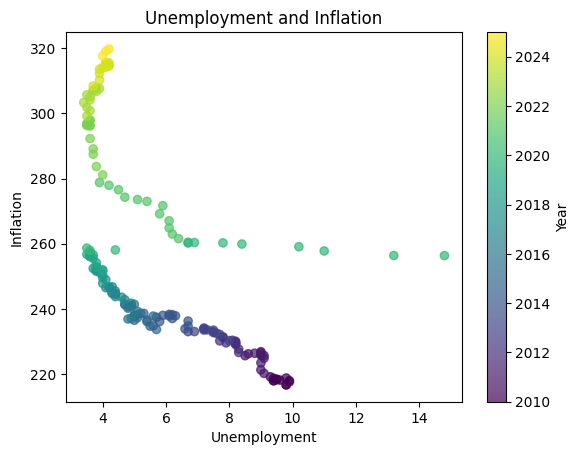

In [ ]:
plt.scatter(unemployment_df['rate'], inflation_df['rate'], c=unemployment_df['date'].dt.year, alpha=0.7)
plt.colorbar(label='Year')
plt.title('Unemployment and Inflation')
plt.xlabel('Unemployment')
plt.ylabel('Inflation')
plt.show()

In [ ]:
before_2020 = unemployment_before.merge(inflation_before, on='date', suffixes=('_unemployment', '_inflation'))
after_2020 = unemployment_after.merge(inflation_after, on='date', suffixes=('_unemployment', '_inflation'))
print(before_2020.head())
print(after_2020.head())

   Year_unemployment Month_unemployment  rate_unemployment       date  \
0               2010                Jan                9.8 2010-01-01   
1               2010                Feb                9.8 2010-02-01   
2               2010                Mar                9.9 2010-03-01   
3               2010                Apr                9.9 2010-04-01   
4               2010                May                9.6 2010-05-01   

   Year_inflation Month_inflation  rate_inflation  
0            2010             Jan         216.687  
1            2010             Feb         216.741  
2            2010             Mar         217.631  
3            2010             Apr         218.009  
4            2010             May         218.178  
   Year_unemployment Month_unemployment  rate_unemployment       date  \
0               2021                Jan                6.4 2021-01-01   
1               2021                Feb                6.2 2021-02-01   
2               2021          

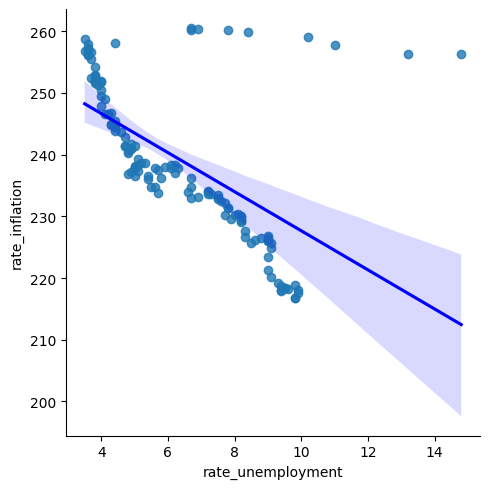

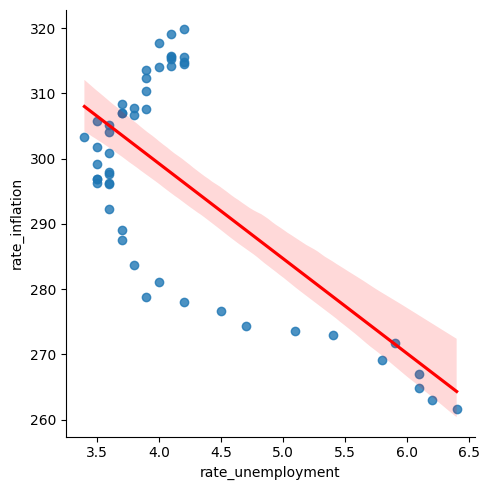

In [ ]:
sns.lmplot(x='rate_unemployment', y='rate_inflation', data=before_2020, line_kws={'color': 'blue'})
sns.lmplot(x='rate_unemployment', y='rate_inflation', data=after_2020, line_kws={'color': 'red'})
plt.show()

In [ ]:
print(before_2020['rate_unemployment'].corr(before_2020['rate_inflation']))
print(after_2020['rate_unemployment'].corr(after_2020['rate_inflation']))

-0.5909585986135723
-0.6870834779310401


### We can conclude that that there is a negative correlation between unemployment and inflation!